# Deriving $\mathbb{E}[\max$ of 10 Standard Normals$]$

In the **10-armed testbed** (Sutton & Barto, Section 2.3), each arm's true value
$q_*(a)$ is drawn independently from $\mathcal{N}(0,1)$. The best possible
average reward — the upper bound in Figure 2.2 — is the expected value of the
maximum arm:

$$\mathbb{E}\!\left[\max(X_1, \ldots, X_{10})\right], \quad X_i \stackrel{\text{i.i.d.}}{\sim} \mathcal{N}(0,1)$$

The file `best_reward_per_step.py` estimates this via Monte Carlo ($\approx 1.54$).
Here we derive it analytically using **order statistics** and evaluate the
integral numerically.

In [1]:
%%capture
%pip install scipy matplotlib numpy

## Order Statistics: CDF and PDF of the Maximum

Let $X_1, \ldots, X_n$ be i.i.d. with CDF $F(x)$ and PDF $f(x)$.
Define $M = \max(X_1, \ldots, X_n)$.

**CDF of $M$:**

$$F_M(x) = P(M \le x) = P(X_1 \le x,\; X_2 \le x,\; \ldots,\; X_n \le x)$$

Since the $X_i$ are independent:

$$F_M(x) = P(X_1 \le x) \cdot P(X_2 \le x) \cdots P(X_n \le x) = [F(x)]^n$$

**PDF of $M$:**

Differentiate using the chain rule:

$$f_M(x) = \frac{d}{dx}[F(x)]^n = n\,[F(x)]^{n-1}\,f(x)$$

This is the density of the $n$-th order statistic (the maximum) of $n$ i.i.d.
random variables.

## Applying to the Standard Normal

For $X_i \sim \mathcal{N}(0,1)$, denote the PDF and CDF by $\varphi(x)$ and
$\Phi(x)$:

$$\varphi(x) = \frac{1}{\sqrt{2\pi}}\,e^{-x^2/2}, \qquad \Phi(x) = \int_{-\infty}^{x} \varphi(t)\,dt$$

Substituting into the order-statistic PDF:

$$f_M(x) = n\,\varphi(x)\,[\Phi(x)]^{n-1}$$

The expected value of the maximum is therefore:

$$\boxed{\mathbb{E}[M] = \int_{-\infty}^{\infty} x \;\cdot\; n\,\varphi(x)\,[\Phi(x)]^{n-1}\;dx}$$

## Why No Closed-Form Solution?

The factor $[\Phi(x)]^{n-1}$ involves the Gaussian CDF raised to a power.
Since $\Phi(x)$ itself has no elementary closed form, neither does this
integral for general $n$. We therefore evaluate it numerically.

## Numerical Evaluation

In [2]:
import numpy as np
from scipy import integrate
from scipy.stats import norm


def expected_max_normal(n):
    """E[max of n i.i.d. standard normals] via numerical integration."""
    def integrand(x):
        return x * n * norm.pdf(x) * norm.cdf(x) ** (n - 1)
    result, _ = integrate.quad(integrand, -10, 10)
    return result


e_max_10 = expected_max_normal(10)
print(f"E[max of 10 standard normals] = {e_max_10:.4f}")

E[max of 10 standard normals] = 1.5388


## Monte Carlo Verification

We reproduce the simulation from `best_reward_per_step.py` and compare.

In [3]:
rng = np.random.default_rng(seed=42)
num_problems = 2_000_000
num_arms = 10

testbed = rng.standard_normal((num_problems, num_arms))
mc_estimate = testbed.max(axis=1).mean()

print(f"Monte Carlo estimate (n=10): {mc_estimate:.4f}")
print(f"Numerical integral  (n=10): {e_max_10:.4f}")
print(f"Difference:                  {abs(mc_estimate - e_max_10):.4f}")

Monte Carlo estimate (n=10): 1.5384
Numerical integral  (n=10): 1.5388
Difference:                  0.0004


## Generalization: E[max] as a Function of n

How does the upper bound on average reward grow with the number of arms?
Below we plot $\mathbb{E}[\max(X_1,\ldots,X_n)]$ for $n = 1, \ldots, 50$.

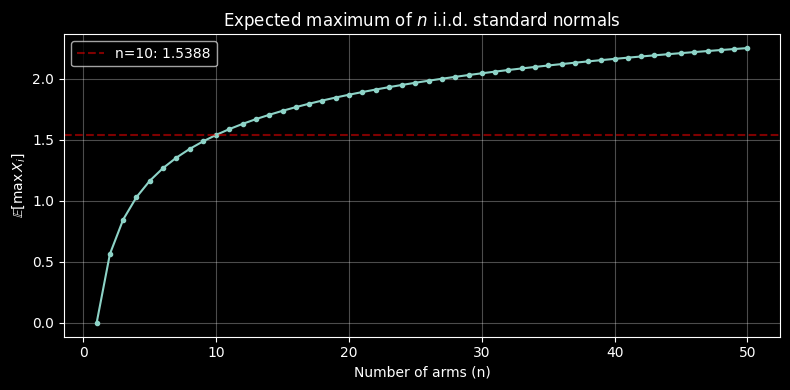

In [4]:
import matplotlib.pyplot as plt

ns = np.arange(1, 51)
e_maxs = [expected_max_normal(n) for n in ns]

plt.figure(figsize=(8, 4))
plt.plot(ns, e_maxs, "o-", markersize=3)
plt.axhline(e_max_10, color="red", linestyle="--", alpha=0.5,
            label=f"n=10: {e_max_10:.4f}")
plt.xlabel("Number of arms (n)")
plt.ylabel(r"$\mathbb{E}[\max\, X_i]$")
plt.title(r"Expected maximum of $n$ i.i.d. standard normals")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()